In [50]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob
import sys
import pdb
sys.path.insert(1, '/Users/joe/repos/climate_utils')
import climate_toolbox as ctb
%matplotlib inline
from datetime import datetime
from scipy.optimize import curve_fit
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import to_rgba

import OCO_v11MIP_analysis as oco

In [5]:
all_obs = ['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS', 'Prior']

# get ensemble data
ens_dict     = {}
ens_tm5_dict = {}
ens_gc_dict  = {}
for obs in all_obs:
    ens_dict[obs]     = oco.get_ensemble(obs)
    ens_tm5_dict[obs] = oco.get_tm5_ensemble(obs)
    ens_gc_dict[obs]  = oco.get_gc_ensemble(obs)

print('done')

working on ocean_flux flux
working on land_flux flux


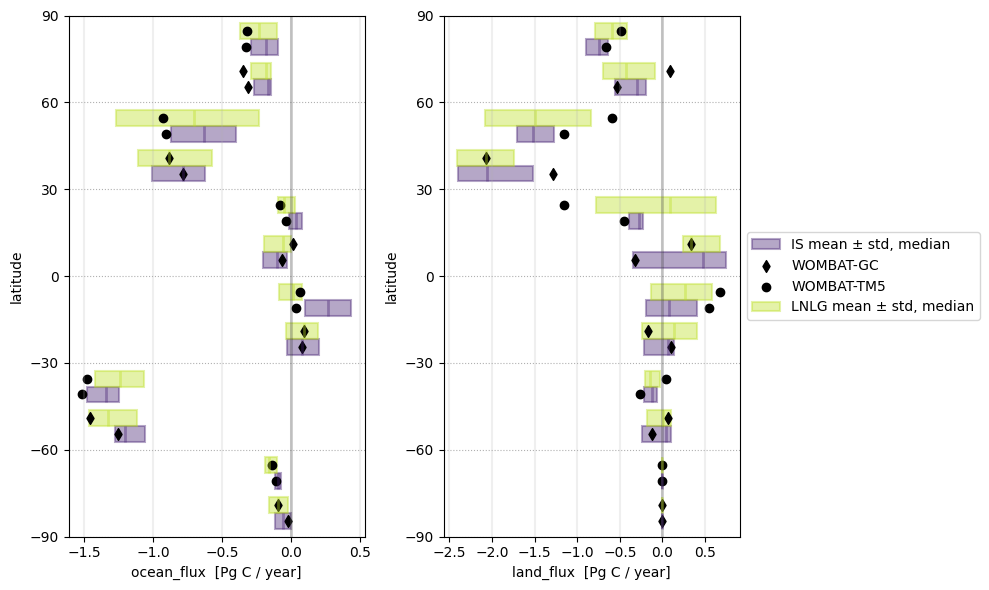

In [10]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_avgflux_bands_plot(include_obs, fname):
    # ----- define latitude bands
    dlat  = 30
    latS  = np.arange(-90, 90-dlat+1, dlat)
    latN  = np.arange(-90+dlat, 90+1, dlat)
    latc  = np.arange(-90+dlat/2, 90-dlat/2 + 1, dlat)
    
    include_ensmean = False
    if(include_ensmean): ng = 3
    else:                ng = 2
    
    Nobs  = len(include_obs)
    pad   = 8
    ddlat = dlat/(Nobs*ng) - pad/(Nobs*ng)
    
    # ----- defined colors per obs set
    colors = np.atleast_1d(plt.cm.viridis(np.linspace(0.1, 0.9, Nobs)))
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 12 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in bands
    for k,flux in enumerate(['ocean_flux', 'land_flux']):
        print(f'working on {flux} flux')
        ax = axes[k]
        ax.yaxis.set_ticks(np.unique(np.hstack([latS, latN])))
        ax.set_ylim([-90, 90])
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg C / year]')
        ax.set_ylabel('latitude')
        
        for i in range(len(latS)):
            print(f'working on lat band {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue

                # ------ get ensemble data
                ens     = ens_dict[obs][flux]
                ens_tm5 = ens_tm5_dict[obs][flux]
                ens_gc  = ens_gc_dict[obs][flux]
    
                # ------ select on obs, flux, take band mean, take time mean, scale to PgC/yr
                band_ens     = oco.lat_band_aggregate(ens, latS[i], latN[i])
                band_tm5_ens = oco.lat_band_aggregate(ens_tm5, latS[i], latN[i])
                band_gc_ens  = oco.lat_band_aggregate(ens_gc, latS[i], latN[i])
    
                # ----- get time mean, 2015-2019
                band_ens     = band_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                band_gc_ens  = band_gc_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                band_tm5_ens = band_tm5_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    
                if(include_ensmean):
                    band_ens_all = [band_gc_ens, band_tm5_ens, band_ens]
                else:
                    band_ens_all = [band_gc_ens, band_tm5_ens]
    
                for l in range(ng):
                    # ------ get medians, deviations, lower y-position of bar
                    y = latS[i] + (j+l*Nobs)*ddlat + pad/(ng+1) * (l+1)
                    x  = float(band_ens_all[l].median('model'))
                    xm = float(band_ens_all[l].mean('model')) 
                    xe = float(band_ens_all[l].std('model'))
        
                    # ------ get colors
                    fcolor = colors[j]
                    fcolor[-1] = 0.4
                    ecolor = colors[j]

                    # ------ get labels
                    if(i==0 and k==1 and l==0): label = f'{obs} mean ± std, median'
                    else:     label = None
        
                    # ------ rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xm - xe, y),  # bottom-left corner
                           2*xe, ddlat,  # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(x, y, y+ddlat, color=ecolor, linewidth=2)
    
                    # ------ plot WOMBAT
                    y = y + ddlat/2
                    if(l==0):   
                        x = band_ens.sel(model='WOMBAT-GC')
                        marker='d'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-GC'
                        else:              label = None
                    elif(l==1): 
                        x = band_ens.sel(model='WOMBAT-TM5')
                        marker='o'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-TM5'
                        else:              label = None
                    ax.scatter(x, y, color='k', marker=marker, label=label)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    #fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
#make_avgflux_bands_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='avgflux_bands_allobs')
make_avgflux_bands_plot(['IS', 'LNLG'], fname='avgflux_bands_IS_LNLG')

working on ocean_flux flux
working on land_flux flux


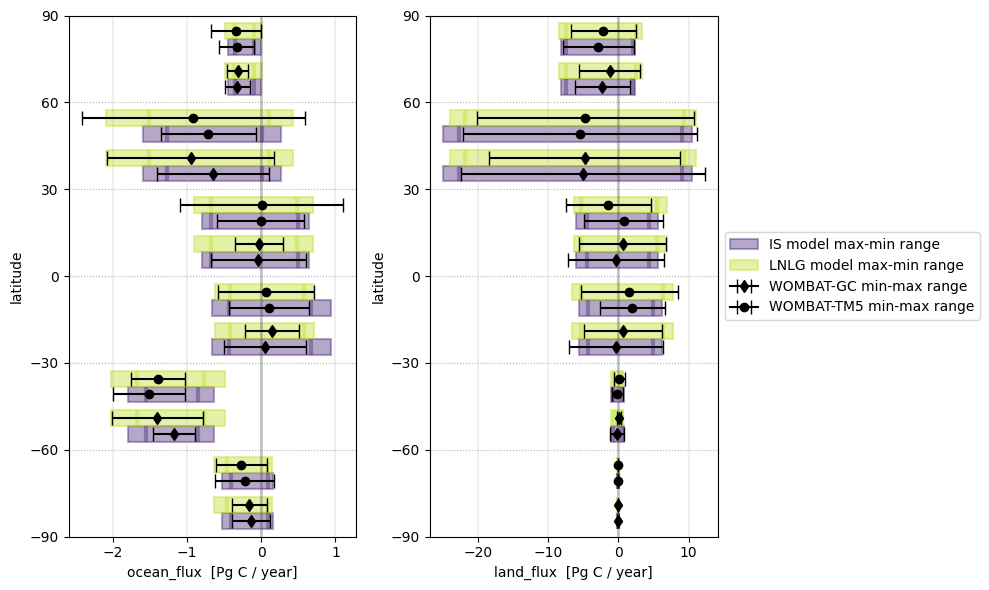

In [16]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_fluxrange_bands_plot(include_obs, fname):
    # ----- define latitude bands
    dlat  = 30
    latS  = np.arange(-90, 90-dlat+1, dlat)
    latN  = np.arange(-90+dlat, 90+1, dlat)
    latc  = np.arange(-90+dlat/2, 90-dlat/2 + 1, dlat)
    
    Nobs  = len(include_obs)
    pad   = 8
    ddlat = dlat/(Nobs*ng) - pad/(Nobs*ng)
    
    # ----- defined colors per obs ser
    colors = np.atleast_1d(plt.cm.viridis(np.linspace(0.1, 0.9, Nobs)))
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 12 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in bands
    for k,flux in enumerate(['ocean_flux', 'land_flux']):
        print(f'working on {flux} flux')
        ax = axes[k]
        ax.yaxis.set_ticks(np.unique(np.hstack([latS, latN])))
        ax.set_ylim([-90, 90])
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg C / year]')
        ax.set_ylabel('latitude')
        
        for i in range(len(latS)):
            print(f'working on lat band {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue
    
                # ------ get ensemble data
                ens_tm5 = ens_tm5_dict[obs][flux]
                ens_gc  = ens_gc_dict[obs][flux]
                
                # ------ select on obs, flux, take band mean, take time mean, scale to PgC/yr
                band_tm5_ens = oco.lat_band_aggregate(ens_tm5, latS[i], latN[i])
                band_gc_ens  = oco.lat_band_aggregate(ens_gc, latS[i], latN[i])

                # ------ get climatology
                band_gc_ens_climo  = ctb.compute_climatology(band_ens)
                band_tm5_ens_climo = ctb.compute_climatology(band_ens)
                band_ens_all = [band_gc_ens_climo, band_tm5_ens_climo]
    
                for l in range(2):
                    # ------ get medians, deviations, lower y-position of bar
                    y = latS[i] + (j+l*Nobs)*ddlat + pad/(ng+1) * (l+1)
                    xmax, xmaxe = float(band_ens_all[l].max('month').mean('model')),\
                                  float(band_ens_all[l].max('month').std('model'))
                    xmin, xmine = float(band_ens_all[l].min('month').mean('model')),\
                                  float(band_ens_all[l].min('month').std('model'))
                    
                    # ------ get colors
                    fcolor = colors[j]
                    fcolor[-1] = 0.4
                    ecolor = colors[j]

                    # ------ get labels
                    if(i==0 and k==1 and l==0): label = f'{obs} model max-min range'
                    else:     label = None
        
                    # ------ rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xmin-xmine, y),                   # bottom-left corner
                           (xmax+xmaxe)-(xmin-xmine), ddlat,  # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(xmin, y, y+ddlat, color=ecolor, linewidth=3)
                    ax.vlines(xmax, y, y+ddlat, color=ecolor, linewidth=3)
    
                    # ------ plot WOMBAT
                    y = y + ddlat/2
                    if(l==0):   
                        xmax = band_ens_climo.sel(model='WOMBAT-GC').max('month')
                        xmin = band_ens_climo.sel(model='WOMBAT-GC').min('month')
                        marker='d'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-GC min-max range'
                        else:              label = None
                    elif(l==1):
                        xmax = band_ens_climo.sel(model='WOMBAT-TM5').max('month')
                        xmin = band_ens_climo.sel(model='WOMBAT-TM5').min('month')
                        marker='o'
                        if(i==0 and k==1 and j==0): label = f'WOMBAT-TM5 min-max range'
                        else:              label = None
                    x = (xmax+xmin)/2
                    ax.errorbar(x, y, xerr=[[abs(xmin-x)],[abs(xmax-x)]], color='k', 
                                marker=marker, label=label, capsize=5)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    #fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
#make_fluxrange_bands_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='fluxrange_bands_allobs')
make_fluxrange_bands_plot(['IS', 'LNLG'], fname='fluxrange_bands_IS_LNLG')

working on ocean_flux
working on land_fluxregion 10


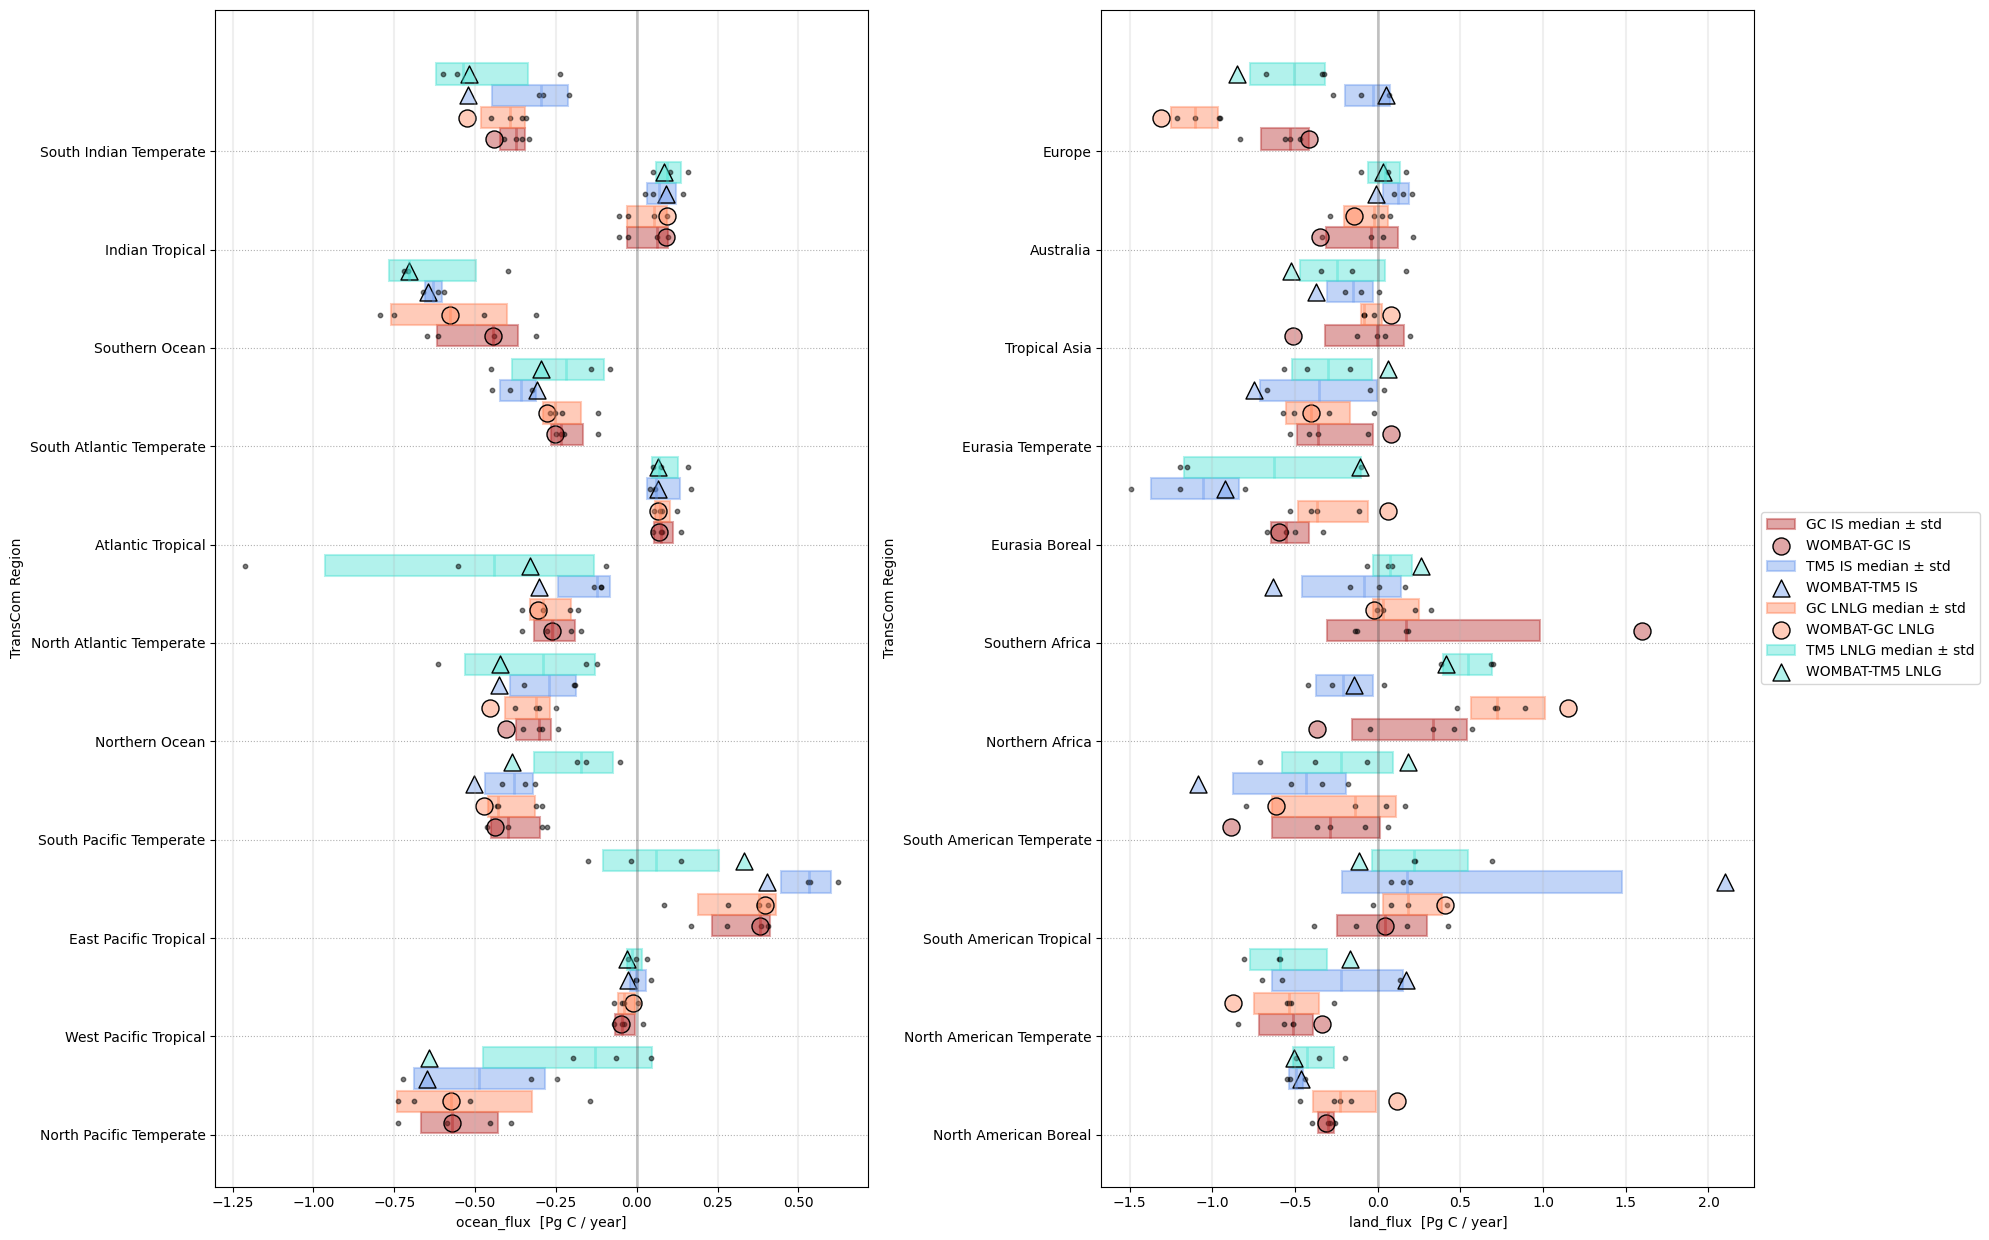

In [73]:
# ---------- compute net climatological fluxes per latitude band, as ensemble mean, transport ensemble means, WOMBAT

def make_avgflux_transcom_plot(include_obs, fname):

    # ---- get all region IDs ----
    all_regions = np.array(list(oco.get_region_list().keys()))
    Nregions    = len(all_regions)
    Nobs        = len(include_obs)
    
    # ----- defined colors per obs ser
    colors = {'IS':{'GC':'firebrick', 'TM5':'cornflowerblue'}, 'LNLG':{'GC':'coral', 'TM5':'turquoise'}}
    
    # ----- create figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 25 * len(include_obs)/4))
    
    # ----- compute medians and deviations for model groups in regions
    for k,flux in enumerate(['ocean_flux', 'land_flux']):

        if(flux == 'ocean_flux'):
            regions = all_regions[np.logical_and(all_regions > 11, all_regions < 23)]
        if(flux == 'land_flux'):
            regions = all_regions[all_regions <= 11]

        # ------ plotting parameters
        dy    = 1/len(regions)
        pad   = 0.005
        ddy   = dy/(Nobs*2) - pad/(Nobs*2)

        # ----- configure axes
        print(f'working on {flux}')
        ax = axes[k]
        ax.yaxis.set_ticks(np.linspace(0, 1, len(regions)))
        ax.yaxis.set_ticklabels([oco.get_region_list()[ri] for ri in regions])
        ax.grid(axis='y', linestyle=':')
        ax.grid(axis='x', linestyle='-', alpha=0.2, lw=1.5)
        ax.axvline(x=0, linestyle='-', color='k', lw=2, alpha=0.2)
        ax.set_xlabel(f'{flux}  [Pg C / year]')
        ax.set_ylabel('TransCom Region')
        
        for i,region in enumerate(regions):
            print(f'working on transcom region {i}', end='\r')
            
            for j,obs in enumerate(include_obs):
                if obs == 'Prior': continue

                # get ensemble data
                ens_tm5 = ens_tm5_dict[obs][flux]
                ens_gc  = ens_gc_dict[obs][flux]

                # select on obs, flux, take band mean, take time mean, scale to PgC/yr
                region_tm5_ens = oco.region_aggregate(ens_tm5, region)
                region_gc_ens  = oco.region_aggregate(ens_gc, region)

                # get time mean, 2015-2019
                region_gc_ens     = region_gc_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                region_tm5_ens    = region_tm5_ens.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
                region_ens_all    = [region_gc_ens, region_tm5_ens]
                region_ens_labels = ['GC', 'TM5']
    
                for l in range(2):
                    # ------ get medians, deviations, lower y-position of bar
                    y = np.linspace(0, 1, len(regions))[i] + (j+l*Nobs)*ddy + pad/(2+1) * (l+1)
                    x  = float(region_ens_all[l].median('model'))
                    xm = float(region_ens_all[l].mean('model'))
                    xe = float(region_ens_all[l].std('model'))
        
                    # get colors
                    fcolor     = list(to_rgba(colors[obs][region_ens_labels[l]]))
                    ecolor     = fcolor
                    fcolor[-1] = 0.4

                    # get labels
                    if(i==0 and k==1): label = f'{region_ens_labels[l]} {obs} median ± std'
                    else:              label = None
        
                    # ------ rectangle showing uncertainty and median
                    rect = Rectangle(
                           (xm - xe, y),  # bottom-left corner
                           2*xe, ddy,     # width and height
                           facecolor=fcolor, edgecolor=ecolor, linewidth=1.5, label=label)
                    ax.add_patch(rect)
                    # center vertical line
                    ax.vlines(x, y, y+ddy, color=ecolor, linewidth=2)

                    # ------ plot all models as faint points
                    y = y + ddy/2
                    mask = region_ens_all[l].model.isin(['WOMBAT-GC', 'WOMBAT-TM5'])
                    model_points = region_ens_all[l].sel(model=~mask)
                    ax.scatter(model_points, np.ones(len(model_points))*y, color='k', marker='o', alpha=0.5, s=10)
    
                    # ------ plot WOMBAT
                    if(l==0):   
                        x = region_gc_ens.sel(model='WOMBAT-GC')
                        marker = 'o'
                        if(i==0 and k==1): label = f'WOMBAT-GC {obs}'
                        else:                       label = None
                    elif(l==1): 
                        x = region_tm5_ens.sel(model='WOMBAT-TM5')
                        marker = '^'
                        if(i==0 and k==1): label = f'WOMBAT-TM5 {obs}'
                        else:                       label = None
                    ax.scatter(x, y, facecolor=fcolor, edgecolor='k', marker=marker, label=label, s=150)

    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    #fig.savefig(f'{fname}.png', dpi=200)
                    
# -------------------------------------------------
# --------- call function and make plots ----------
#make_avgflux_transcom_plot(['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS'], fname='avgflux_transcom_allobs')
make_avgflux_transcom_plot(['IS', 'LNLG'], fname='avgflux_transcom_IS_LNLG')

In [116]:
# Now lets make a simplified plot showing the LNLG-IS difference, for each transport model, for both the ensemble median, and WOMBAT...

all_regions   = np.array(sorted(list(oco.get_region_list().keys())))
ocean_regions = all_regions[np.logical_and(all_regions > 11, all_regions < 23)]
land_regions  = all_regions[all_regions <= 11]

region_ens_diffs     = {'GC':{}, 'TM5':{}}
region_ens_diffs_std = {'GC':{}, 'TM5':{}}
region_wombat_diffs  = {'GC':{}, 'TM5':{}}

colors = {'IS':{'GC':'firebrick', 'TM5':'cornflowerblue'}, 'LNLG':{'GC':'coral', 'TM5':'turquoise'}}

# ------ loop over regions
for region in all_regions:

    if(region in ocean_regions):  flux = 'ocean_flux'
    elif(region in land_regions): flux = 'land_flux' 

    print(f'{flux.split("_")[0]} region {region}', end='\r')

    tm5_lnlg = oco.region_aggregate(ens_tm5_dict['LNLG'][flux], region)
    tm5_is   = oco.region_aggregate(ens_tm5_dict['IS'][flux], region)
    tm5_lnlg = tm5_lnlg.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    tm5_is   = tm5_is.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    tm5_ens_diff    = tm5_lnlg - tm5_is
    tm5_ens_diff_median, tm5_ens_diff_std = tm5_ens_diff.median('model'), tm5_ens_diff.std('model')
    tm5_wombat_diff = tm5_lnlg.sel(model='WOMBAT-TM5') - tm5_is.sel(model='WOMBAT-TM5')
    
    gc_lnlg = oco.region_aggregate(ens_gc_dict['LNLG'][flux], region)
    gc_is   = oco.region_aggregate(ens_gc_dict['IS'][flux], region)
    gc_lnlg = gc_lnlg.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    gc_is   = gc_is.sel(time=slice('2015-01-01', '2020-01-01')).mean('time')
    gc_ens_diff = gc_lnlg - gc_is
    gc_ens_diff_median, gc_ens_diff_std = gc_ens_diff.median('model'), gc_ens_diff.std('model')
    gc_wombat_diff = gc_lnlg.sel(model='WOMBAT-GC') - gc_is.sel(model='WOMBAT-GC')

    region_ens_diffs['TM5'][region]     = tm5_ens_diff_median
    region_ens_diffs_std['TM5'][region] = tm5_ens_diff_std
    region_wombat_diffs['TM5'][region]  = tm5_wombat_diff
    region_ens_diffs['GC'][region]      = gc_ens_diff_median
    region_wombat_diffs['GC'][region]   = gc_wombat_diff
    region_ens_diffs_std['GC'][region]  = gc_ens_diff_std

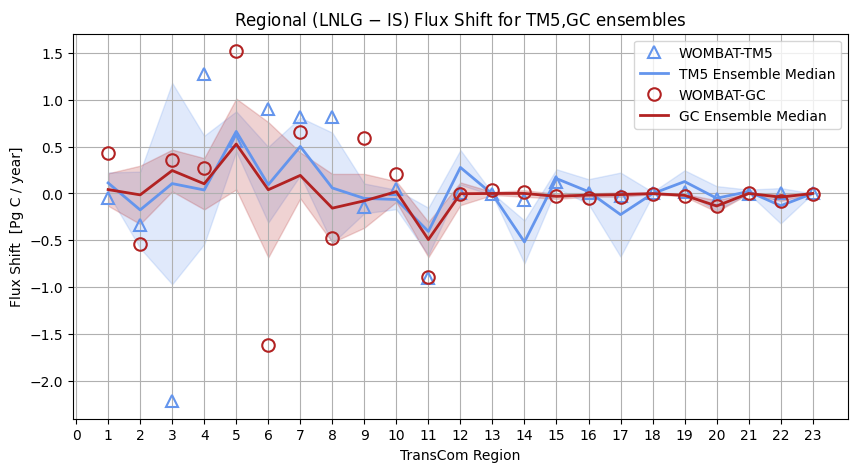

In [152]:
fig = plt.figure(figsize=(10,5))
ax  = fig.add_subplot()

tm5_wombat_y = np.array([region_wombat_diffs['TM5'][ri] for ri in all_regions])
tm5_ens_y    = np.array([region_ens_diffs['TM5'][ri] for ri in all_regions])
tm5_ens_ye   = np.array([region_ens_diffs_std['TM5'][ri] for ri in all_regions])
gc_wombat_y  = np.array([region_wombat_diffs['GC'][ri] for ri in all_regions])
gc_ens_y     = np.array([region_ens_diffs['GC'][ri] for ri in all_regions])
gc_ens_ye    = np.array([region_ens_diffs_std['GC'][ri] for ri in all_regions])

# plot WOMBAT TM5
ax.plot(all_regions, [region_wombat_diffs['TM5'][ri] for ri in all_regions], '^', label='WOMBAT-TM5',
        markeredgecolor=colors['IS']['TM5'], markerfacecolor=[0,0,0,0], mew=1.5, ms=9)
# plot TM5 ensemble difference median
ax.plot(all_regions, tm5_y, '-', 
        color=colors['IS']['TM5'], label='TM5 Ensemble Median', lw=2)
# plot TM5 ensemble difference std
ax.fill_between(all_regions, tm5_y-tm5_ye, tm5_y+tm5_ye, color=colors['IS']['TM5'], alpha=0.2)

# plot WOMBAT GC
ax.plot(all_regions, [region_wombat_diffs['GC'][ri] for ri in all_regions], 'o', label='WOMBAT-GC',
        markeredgecolor=colors['IS']['GC'], markerfacecolor=[0,0,0,0], mew=1.5, ms=9)
# plot GC ensemble difference median
ax.plot(all_regions, gc_y, '-', 
        color=colors['IS']['GC'], label='GC Ensemble Median', lw=2)
# plot GC ensemble difference std
ax.fill_between(all_regions, gc_y-gc_ye, gc_y+gc_ye, color=colors['IS']['GC'], alpha=0.2)

_ = ax.xaxis.set_ticks(np.arange(0,24,1))
_ = ax.set_xlabel('TransCom Region')
_ = ax.set_ylabel('Flux Shift  [Pg C / year]')
ax.set_title('Regional (LNLG $-$ IS) Flux Shift for TM5,GC ensembles')
plt.grid()
plt.legend()

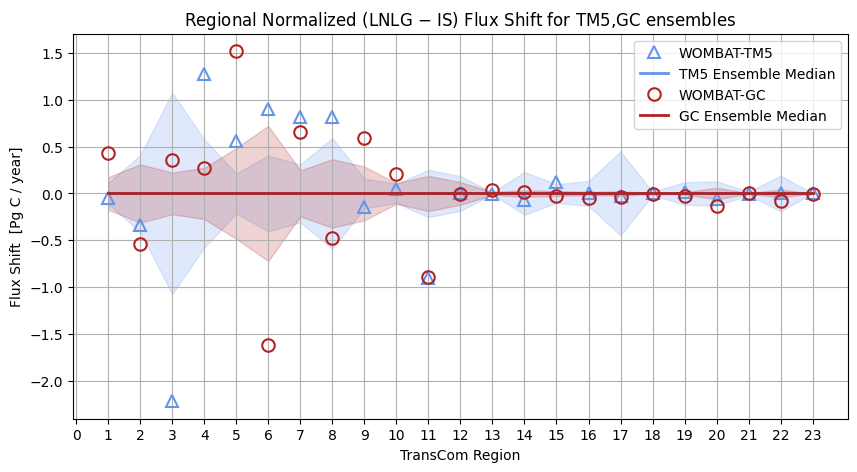

In [156]:
fig = plt.figure(figsize=(10,5))
ax  = fig.add_subplot()

tm5_wombat_y = np.array([region_wombat_diffs['TM5'][ri] for ri in all_regions])
tm5_ens_y    = np.array([region_ens_diffs['TM5'][ri] for ri in all_regions])
tm5_ens_ye   = np.array([region_ens_diffs_std['TM5'][ri] for ri in all_regions])
gc_wombat_y  = np.array([region_wombat_diffs['GC'][ri] for ri in all_regions])
gc_ens_y     = np.array([region_ens_diffs['GC'][ri] for ri in all_regions])
gc_ens_ye    = np.array([region_ens_diffs_std['GC'][ri] for ri in all_regions])

# plot WOMBAT TM5
ax.plot(all_regions, [region_wombat_diffs['TM5'][ri] for ri in all_regions], '^', label='WOMBAT-TM5',
        markeredgecolor=colors['IS']['TM5'], markerfacecolor=[0,0,0,0], mew=1.5, ms=9)
# plot TM5 ensemble difference median
ax.plot(all_regions, tm5_y-tm5_y, '-', 
        color=colors['IS']['TM5'], label='TM5 Ensemble Median', lw=2)
# plot TM5 ensemble difference std
ax.fill_between(all_regions, -tm5_ye, +tm5_ye, color=colors['IS']['TM5'], alpha=0.2)

# plot WOMBAT GC
ax.plot(all_regions, [region_wombat_diffs['GC'][ri] for ri in all_regions], 'o', label='WOMBAT-GC',
        markeredgecolor=colors['IS']['GC'], markerfacecolor=[0,0,0,0], mew=1.5, ms=9)
# plot GC ensemble difference median
ax.plot(all_regions, gc_y-gc_y, '-', 
        color=colors['IS']['GC'], label='GC Ensemble Median', lw=2)
# plot GC ensemble difference std
ax.fill_between(all_regions, -gc_ye, +gc_ye, color=colors['IS']['GC'], alpha=0.2)

_ = ax.xaxis.set_ticks(np.arange(0,24,1))
_ = ax.set_xlabel('TransCom Region')
_ = ax.set_ylabel('Flux Shift  [Pg C / year]')
ax.set_title('Regional Normalized (LNLG $-$ IS) Flux Shift for TM5,GC ensembles')
plt.grid()
plt.legend()

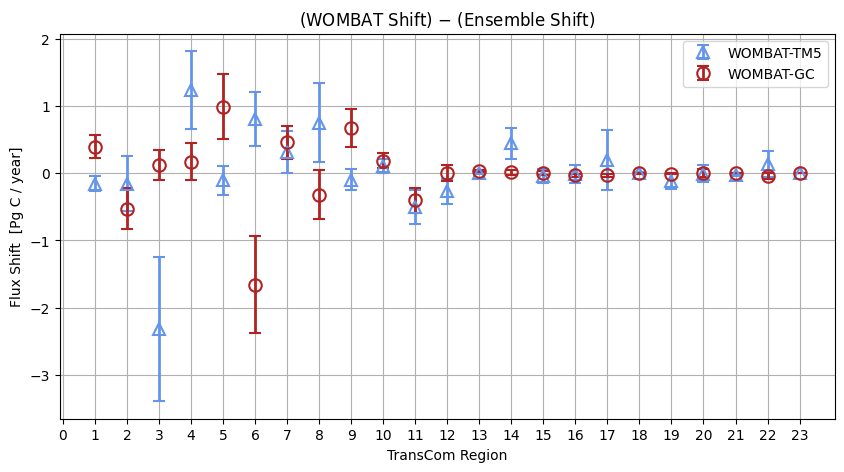

In [154]:
fig = plt.figure(figsize=(10,5))
ax  = fig.add_subplot()

ax.errorbar(all_regions, tm5_wombat_y - tm5_ens_y, yerr = tm5_ens_ye,
            label='WOMBAT-TM5', lw=0, elinewidth=2, mew=1.5, ms=9, capsize=4,
            marker='^', color=colors['IS']['TM5'], markeredgecolor=colors['IS']['TM5'], markerfacecolor=[0,0,0,0])
ax.errorbar(all_regions, gc_wombat_y - gc_ens_y, yerr = gc_ens_ye,
            label='WOMBAT-GC', lw=0, elinewidth=2, mew=1.5, ms=9, capsize=4, 
            marker='o', color=colors['IS']['GC'], markeredgecolor=colors['IS']['GC'], markerfacecolor=[0,0,0,0])


_ = ax.xaxis.set_ticks(np.arange(0,24,1))
_ = ax.set_xlabel('TransCom Region')
_ = ax.set_ylabel('Flux Shift  [Pg C / year]')
ax.set_title('(WOMBAT Shift) $-$ (Ensemble Shift)')
plt.grid()
plt.legend()

Notes after comparing to 2d maps:

Southern Africa (6):

- GC, LNLG: looks fine
- TM5, LNLS: looks fine
- **GC, IS: Wombat strong outlier; huge source near northern end of region**
- TM5, IS: looks fine

Northern Africa (5): 

- GC, LNLG, Northern Africa: looks okay
- TM5, LNLG, Northern Africa: looks okay
- **GC, IS: Wombat strong outlier, huge sink near southern end of region**
- *TM5, IS: looks meh, strong local sinks and sources, but total looks okay*

Southern South America (4):

- GC, LNLG: looks alright
- TM5, LNLG: looks alright (although simulates a difference pattern; only model to predicts sources down the eastern coast
- **GC, IS: Wombat strong outlier, huge sink in the central region, large sources on the easter coast and the NW region oundary**
- *TM5, IS: Looks kinda alright, some outlier behavior, large sinks near regions center, and NW edge*

Tropical South America (3):

- GC, LNLG: looks alright
- TM5, LNLG: looks alright, Wombat has minor outlier sinks along the northern edge of region
- *GC, IS: looks alright, large sink in center of region, and strong sources along perimeter*
- **TM5, IS: Wombat huge outlier, massive source to the E, massive sink to the W**